# Notebook 10 — Multi-Pair Portfolio with Equal Risk Contribution

**Adaptive Pair Trading | Ayush Arora (MQMS2404)**

---

## What this notebook does

Constructs a risk-diversified portfolio from **the pairs NB08 selected**
(`data/top_pairs.csv`, read directly — no hardcoded fallback):

1. **Kalman Filter** adaptive hedge ratio per pair
2. **Z-score signal** per pair — `config.rolling_zscore` (252/60)
3. **P&L as a return on deployed capital** — `config.pair_backtest`
   (gross exposure `price_A + |β|·price_B`), swept at **10 / 30 / 60 bps** round trip
4. **Cross-pair return correlation**
5. **Equal Risk Contribution (ERC)** weights
6. **Portfolio analytics** — Sharpe (full daily series), drawdown (guarded),
   diversification ratio

**These are in-sample, full-history (2015–2024) numbers** — a portfolio-construction
illustration. The out-of-sample test lives in NB09.

### What this pass fixed
The previous P&L divided spread changes by the mean spread level — no capital
base, unbounded, and `(1+pnl).cumprod()` crossed zero (Max DD printed as
−1.3e13 %). It is now a return on gross exposure, bounded below by −100 % and
asserted. Sharpe is over the full daily series (flat days included), not active
days only. Costs are a two-leg round-trip parameter, swept, not a single
one-way 10 bps charge.

### What is ERC?
Weights chosen so **every pair contributes the same share of portfolio
volatility**. For `n` pairs with covariance Σ:
```
min_w  Σᵢ (RC_i − 1/n)²   s.t.  Σᵢ wᵢ = 1,  PORT_MIN_WEIGHT ≤ wᵢ ≤ PORT_MAX_WEIGHT
where RC_i = wᵢ · (Σw)_i / √(wᵀΣw)
```

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize
import warnings
from config import (
    PRICES_FILE, TOP_PAIRS_FILE,
    ROLL_WINDOW, ROLL_MIN_PERIODS, rolling_zscore,
    ENTRY_Z, EXIT_Z,
    COST_BPS_ROUND_TRIP, COST_BPS_ROUND_TRIP_LEVELS,
    pair_backtest, sharpe_ratio, max_drawdown,
    KF_DELTA, KF_INIT_P,
    PORT_TOP_PAIRS, PORT_MAX_WEIGHT, PORT_MIN_WEIGHT,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
COST_LEVELS = list(COST_BPS_ROUND_TRIP_LEVELS)   # (10, 30, 60) bps round trip
BASE_COST   = COST_BPS_ROUND_TRIP                 # used for ERC weights / correlation
print('Libraries loaded. Cost levels (bps round trip):', COST_LEVELS,
      '| base', BASE_COST)

Libraries loaded. Cost levels (bps round trip): [10, 30, 60] | base 30


In [2]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)

# ── Top pairs come from NB08 — no silent fallback ─────────────────────────
# A silent fallback to a hardcoded list changes what the portfolio is measuring
# without telling anyone. Missing file => stop and point at NB08.
if not os.path.exists(TOP_PAIRS_FILE):
    raise FileNotFoundError(
        f'{TOP_PAIRS_FILE} not found. Run _08_Universe_Pair_Scan.ipynb first — '
        'it writes the ranked pair list that this portfolio is built from.'
    )

top_pairs_df = pd.read_csv(TOP_PAIRS_FILE, index_col=0)
top_pairs = [
    (a, b) for a, b in zip(top_pairs_df['Stock A'], top_pairs_df['Stock B'])
    if a in prices.columns and b in prices.columns
]
if not top_pairs:
    raise ValueError(f'No usable pairs in {TOP_PAIRS_FILE} (tickers not in {PRICES_FILE}).')

n_available = len(top_pairs)
top_pairs = top_pairs[:PORT_TOP_PAIRS]
print(f'Loaded {n_available} pair(s) from {TOP_PAIRS_FILE}; '
      f'using top {len(top_pairs)} (PORT_TOP_PAIRS={PORT_TOP_PAIRS}).')
if n_available < PORT_TOP_PAIRS:
    print(f'NOTE: only {n_available} pair(s) cleared NB08 — portfolio has fewer '
          f'names than the {PORT_TOP_PAIRS}-pair target.')

for a, b in top_pairs:
    print(f'  {a.replace(".NS",""):15s} / {b.replace(".NS","")}')

Loaded 3 pair(s) from data/top_pairs.csv; using top 3 (PORT_TOP_PAIRS=5).
NOTE: only 3 pair(s) cleared NB08 — portfolio has fewer names than the 5-pair target.
  DABUR           / HINDUNILVR
  GRASIM          / HINDALCO
  HINDALCO        / TATASTEEL


## Section 1: Kalman Filter Adaptive Hedge Ratio for Each Pair

The same Kalman Filter from NB07 is applied to every pair independently.
This eliminates static-β look-ahead bias and allows each relationship to
evolve at its own pace.

In [3]:
def kalman_hedge(y, x, delta=KF_DELTA):
    """Kalman filter for time-varying [alpha_t, beta_t]. See NB07 for derivation."""
    n     = len(y)
    theta = np.zeros((n, 2))
    P     = np.eye(2) * KF_INIT_P
    Q     = delta / (1 - delta) * np.eye(2)
    R     = 1.0
    kf_e  = np.zeros(n)

    for t in range(n):
        H       = np.array([[1.0, x.iloc[t]]])
        t_pred  = theta[t-1] if t > 0 else np.zeros(2)
        P_pred  = P + Q
        y_hat   = float(H @ t_pred)
        e       = y.iloc[t] - y_hat
        S       = float(H @ P_pred @ H.T) + R
        R       = 0.95 * R + 0.05 * e ** 2
        K       = P_pred @ H.T / S
        theta[t] = t_pred + K.flatten() * e
        P        = (np.eye(2) - K @ H) @ P_pred
        kf_e[t]  = e

    return (
        pd.Series(theta[:, 0], index=y.index, name='kf_alpha'),
        pd.Series(theta[:, 1], index=y.index, name='kf_beta'),
        pd.Series(kf_e,        index=y.index, name='kf_spread'),
    )

print('Kalman filter defined.')

Kalman filter defined.


In [4]:
pair_data = {}
for a, b in top_pairs:
    kf_alpha, kf_beta, kf_spread = kalman_hedge(prices[a], prices[b])
    # Rolling Z-score on Kalman innovations — the ONE definition (config.rolling_zscore),
    # same 252/60 as NB03 and NB09. No look-ahead.
    kf_zscore = rolling_zscore(kf_spread)
    label = f'{a.replace(".NS","")} / {b.replace(".NS","")}'
    pair_data[label] = {
        'a': a, 'b': b,
        'kf_beta':   kf_beta,
        'kf_spread': kf_spread,
        'kf_zscore': kf_zscore,
    }
    print(f'{label:35s} β range [{kf_beta.min():.3f}, {kf_beta.max():.3f}]')

print(f'\nKalman filter estimated for {len(pair_data)} pairs.')

DABUR / HINDUNILVR                  β range [0.199, 0.387]


GRASIM / HINDALCO                   β range [3.126, 5.604]


HINDALCO / TATASTEEL                β range [3.401, 5.263]

Kalman filter estimated for 3 pairs.


## Section 2: Signal Generation & Individual Pair P&L

In [5]:
# ── Daily P&L per pair, as a return on deployed capital ───────────────────
# config.pair_backtest: long 1 unit A / short |kf_beta| units B, gross exposure
# price_A + |kf_beta|*price_B, P&L divided by exposure at entry. Kalman beta is a
# Series (lagged one day inside pair_backtest -> point-in-time). Full 2015-2024
# history: these are IN-SAMPLE portfolio-construction numbers, not OOS (NB09
# does the OOS test). Swept at 10 / 30 / 60 bps round trip.

def n_trades(pos):
    pos = pd.Series(pos)
    return int(((pos != 0) & (pos.shift(1).fillna(0) == 0)).sum())

ret_by_cost, bt_by_cost = {}, {}
for cost in COST_LEVELS:
    cols, bts = {}, {}
    for label, d in pair_data.items():
        bt = pair_backtest(prices[d['a']], prices[d['b']], d['kf_beta'],
                           d['kf_zscore'], cost_bps_round_trip=cost)
        cols[label] = bt['ret']
        bts[label]  = bt
    ret_by_cost[cost] = pd.DataFrame(cols)
    bt_by_cost[cost]  = bts

ret_df = ret_by_cost[BASE_COST]          # base case -> ERC weights, correlation
assert ret_df.to_numpy().min() > -1.0, 'daily return <= -100% — capital model broken'

for cost in COST_LEVELS:
    rd = ret_by_cost[cost]
    print(f'\n=== PER-PAIR (Kalman hedge) @ {cost} bps round trip ===')
    print(f'{"Pair":<24}{"AnnRet%":>9}{"Vol%":>8}{"Sharpe":>8}{"MaxDD%":>9}'
          f'{"TiM%":>7}{"Trades":>8}{"Hit%":>7}')
    for label in rd.columns:
        r   = rd[label]
        bt  = bt_by_cost[cost][label]
        act = r[r != 0]
        print(f'{label:<24}{r.mean()*252*100:>9.2f}{r.std()*np.sqrt(252)*100:>8.2f}'
              f'{sharpe_ratio(r):>8.3f}{max_drawdown(r):>9.2f}'
              f'{bt["in_market"].mean()*100:>7.1f}{n_trades(bt["pos"]):>8d}'
              f'{(act > 0).mean()*100:>7.1f}')


=== PER-PAIR (Kalman hedge) @ 10 bps round trip ===
Pair                      AnnRet%    Vol%  Sharpe   MaxDD%   TiM%  Trades   Hit%


DABUR / HINDUNILVR           1.24    3.79   0.326    -5.66    6.0      98   34.3
GRASIM / HINDALCO            2.85   10.37   0.275   -32.25   27.6      24   48.7
HINDALCO / TATASTEEL         1.48    7.87   0.187   -20.77   20.9      19   48.4

=== PER-PAIR (Kalman hedge) @ 30 bps round trip ===
Pair                      AnnRet%    Vol%  Sharpe   MaxDD%   TiM%  Trades   Hit%
DABUR / HINDUNILVR          -0.76    3.67  -0.208   -10.44    6.0      98   30.2
GRASIM / HINDALCO            2.36   10.34   0.228   -32.39   27.6      24   48.6
HINDALCO / TATASTEEL         1.09    7.83   0.139   -20.77   20.9      19   48.4

=== PER-PAIR (Kalman hedge) @ 60 bps round trip ===
Pair                      AnnRet%    Vol%  Sharpe   MaxDD%   TiM%  Trades   Hit%
DABUR / HINDUNILVR          -3.77    3.58  -1.053   -32.48    6.0      98   25.7
GRASIM / HINDALCO            1.62   10.30   0.158   -32.59   27.6      24   48.4
HINDALCO / TATASTEEL         0.50    7.78   0.065   -20.77   20.9      19   48.4


## Section 3: Pair P&L Correlation Analysis

The diversification benefit of a multi-pair portfolio depends critically on
how correlated the individual pair P&Ls are. If all pairs make and lose money
together, there is no diversification.

Ideally, cross-sector pairs should have near-zero P&L correlation.

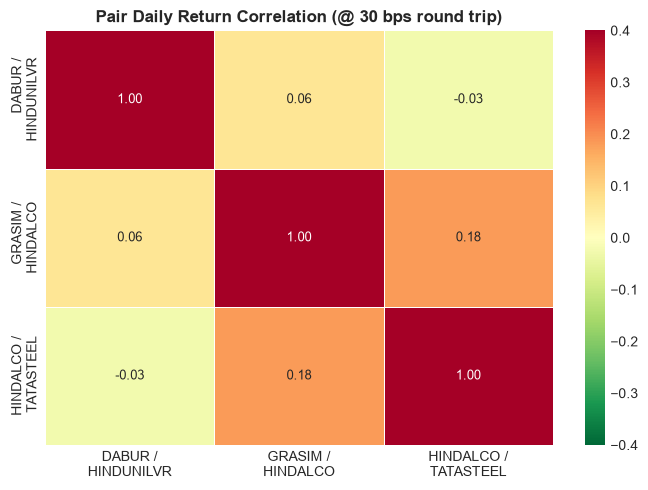

Average pairwise return correlation: 0.074
Diversification present: YES
Note: GRASIM/HINDALCO and HINDALCO/TATASTEEL share the HINDALCO leg with opposite sign, which suppresses (does not eliminate) their dependence.


In [6]:
pnl_corr = ret_df.corr()                       # daily return-on-capital correlation, base cost
short_labels = [c.replace('.NS', '').replace(' / ', ' /\n') for c in ret_df.columns]

fig, ax = plt.subplots(figsize=(max(7, len(ret_df.columns) + 2),
                                max(5, len(ret_df.columns))))
sns.heatmap(
    pnl_corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
    xticklabels=short_labels, yticklabels=short_labels,
    vmin=-0.4, vmax=0.4, center=0, ax=ax, linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title(f'Pair Daily Return Correlation (@ {BASE_COST} bps round trip)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pair_pnl_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

avg_corr = pnl_corr.values[np.triu_indices_from(pnl_corr.values, k=1)].mean()
print(f'Average pairwise return correlation: {avg_corr:.3f}')
print(f'Diversification present: {"YES" if avg_corr < 0.4 else "LIMITED"}')
print('Note: GRASIM/HINDALCO and HINDALCO/TATASTEEL share the HINDALCO leg with '
      'opposite sign, which suppresses (does not eliminate) their dependence.')

## Section 4: Equal Risk Contribution (ERC) Portfolio Weights

ERC ensures every pair contributes the same fraction of total portfolio volatility.
This is more sophisticated than equal-weight (naive) and simpler than
full mean-variance optimisation (which is notoriously sensitive to return estimates).

ERC is used by multi-strategy hedge funds precisely because it requires no return
forecasts — only the covariance matrix, which is estimated from historical data.

In [7]:
def erc_weights(cov, min_w=PORT_MIN_WEIGHT, max_w=PORT_MAX_WEIGHT):
    """Equal Risk Contribution weights via scipy optimisation."""
    n  = len(cov)
    w0 = np.ones(n) / n

    def portfolio_vol(w):
        return np.sqrt(w @ cov @ w)

    def risk_contribution(w):
        vol = portfolio_vol(w)
        mrc = cov @ w
        return w * mrc / (vol + 1e-12)

    def objective(w):
        rc     = risk_contribution(w)
        target = portfolio_vol(w) / n
        return np.sum((rc - target) ** 2)

    result = minimize(
        objective, w0,
        method='SLSQP',
        bounds=[(min_w, max_w)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
        options={'ftol': 1e-12, 'maxiter': 2000}
    )
    if not result.success:
        raise RuntimeError(f'ERC optimiser failed: {result.message}')
    return result.x

n_pairs = ret_df.shape[1]
if n_pairs < 2:
    raise RuntimeError(f'Portfolio needs >= 2 pairs; NB08 delivered {n_pairs}. '
                       'Nothing to diversify.')

# Daily covariance from base-cost return-on-capital series
cov_matrix = ret_df.cov().values
w_erc      = erc_weights(cov_matrix)
w_equal    = np.ones(n_pairs) / n_pairs

print(f'=== Portfolio Weights (weights from {BASE_COST} bps returns) ===')
print(f'\n{"Pair":<40} {"Equal-Weight":>13} {"ERC Weight":>12}')
for label, we, wr in zip(ret_df.columns, w_equal, w_erc):
    print(f'{label:<40} {we*100:>12.1f}% {wr*100:>11.1f}%')

vol_port_erc = np.sqrt(w_erc @ cov_matrix @ w_erc)
rc_erc       = w_erc * (cov_matrix @ w_erc) / vol_port_erc
print(f'\nRisk contribution per pair (ERC):')
for label, rc in zip(ret_df.columns, rc_erc):
    print(f'  {label:<40} {rc / rc_erc.sum() * 100:.1f}%')
print(f'Max deviation from equal contribution: '
      f'{abs(rc_erc/rc_erc.sum() - 1/len(rc_erc)).max()*100:.2f}%')

=== Portfolio Weights (weights from 30 bps returns) ===

Pair                                      Equal-Weight   ERC Weight
DABUR / HINDUNILVR                               33.3%        50.0%
GRASIM / HINDALCO                                33.3%        20.9%
HINDALCO / TATASTEEL                             33.3%        29.1%

Risk contribution per pair (ERC):
  DABUR / HINDUNILVR                       22.9%
  GRASIM / HINDALCO                        38.1%
  HINDALCO / TATASTEEL                     39.0%
Max deviation from equal contribution: 10.42%


## Section 5: Portfolio Equity Curve & Analytics

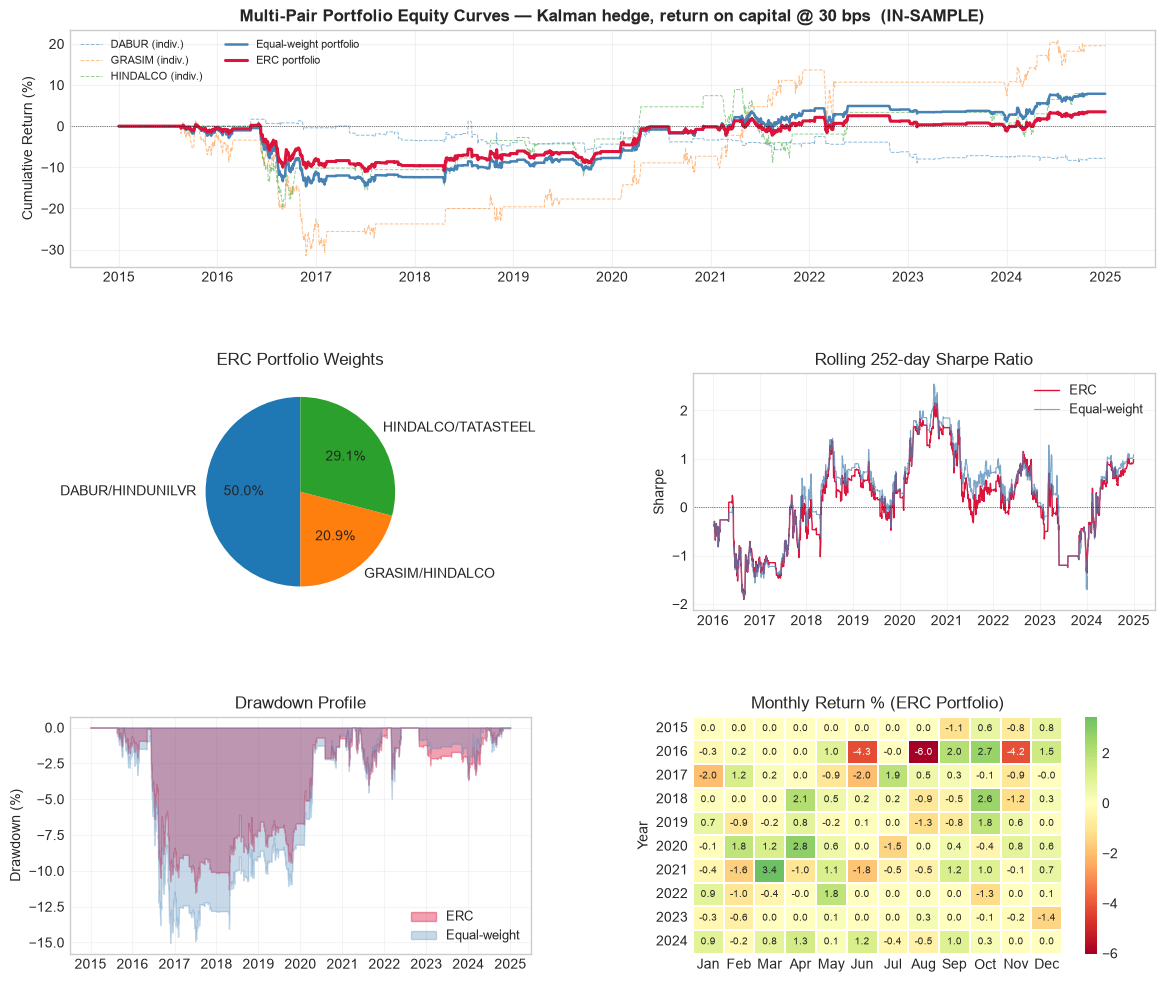

In [8]:
# Portfolio daily returns at the base cost level
pnl_equal = ret_df @ w_equal
pnl_erc   = ret_df @ w_erc

cum_equal = (1 + pnl_equal).cumprod() - 1
cum_erc   = (1 + pnl_erc  ).cumprod() - 1
cum_individuals = {col: (1 + ret_df[col]).cumprod() - 1 for col in ret_df.columns}

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.35)

# ── Main equity curve (return on capital, bounded) ───────────────────────
ax1 = fig.add_subplot(gs[0, :])
for label, cum_i in cum_individuals.items():
    short = label.split('/')[0].strip().replace('.NS', '')
    ax1.plot(cum_i * 100, linewidth=0.7, alpha=0.5, linestyle='--', label=f'{short} (indiv.)')
ax1.plot(cum_equal * 100, color='steelblue', linewidth=1.8, label='Equal-weight portfolio')
ax1.plot(cum_erc   * 100, color='crimson',   linewidth=2.2, label='ERC portfolio')
ax1.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax1.set_title(f'Multi-Pair Portfolio Equity Curves — Kalman hedge, return on capital '
              f'@ {BASE_COST} bps  (IN-SAMPLE)', fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.25)

# ── ERC weights pie ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
short_labels_pie = [c.split('/')[0].strip().replace('.NS', '') + '/' +
                    c.split('/')[1].strip().replace('.NS', '') for c in ret_df.columns]
ax2.pie(w_erc, labels=short_labels_pie, autopct='%1.1f%%', startangle=90)
ax2.set_title('ERC Portfolio Weights')

# ── Rolling 252d Sharpe (full window series) ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
roll_sh_erc = pnl_erc.rolling(252).apply(
    lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan)
roll_sh_eq  = pnl_equal.rolling(252).apply(
    lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan)
ax3.plot(roll_sh_erc, color='crimson',  linewidth=1.0, label='ERC')
ax3.plot(roll_sh_eq,  color='steelblue', linewidth=0.8, alpha=0.7, label='Equal-weight')
ax3.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax3.set_title('Rolling 252-day Sharpe Ratio')
ax3.set_ylabel('Sharpe'); ax3.legend(fontsize=9); ax3.grid(alpha=0.2)

# ── Drawdown ────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
def dd_curve(r):
    c = (1 + r).cumprod()
    return (c - c.cummax()) / c.cummax() * 100
ax4.fill_between(pnl_erc.index,   dd_curve(pnl_erc),   0, alpha=0.4, color='crimson',   label='ERC')
ax4.fill_between(pnl_equal.index, dd_curve(pnl_equal), 0, alpha=0.3, color='steelblue', label='Equal-weight')
ax4.set_title('Drawdown Profile'); ax4.set_ylabel('Drawdown (%)')
ax4.legend(fontsize=9); ax4.grid(alpha=0.2)

# ── Monthly P&L heatmap for ERC ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
monthly_df = (pnl_erc.resample('ME').sum() * 100).to_frame('pnl')
monthly_df['Year']  = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month
try:
    pivot = monthly_df.pivot(index='Year', columns='Month', values='pnl')
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:pivot.shape[1]]
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                ax=ax5, linewidths=0.3, annot_kws={'size': 7})
    ax5.set_title('Monthly Return % (ERC Portfolio)')
except Exception:
    ax5.set_visible(False)

plt.savefig('portfolio_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
def perf_stats(ret, label):
    """Performance of a daily return-on-capital series. Sharpe over the FULL
    series (config.sharpe_ratio); drawdown guarded (config.max_drawdown).
    'Active %' = share of days with non-zero P&L or cost (broader than the
    per-pair 'TiM%' above, which counts only days a position is actually held)."""
    r      = pd.Series(ret)
    ann_r  = r.mean() * 252
    ann_v  = r.std() * np.sqrt(252)
    mdd    = max_drawdown(r)                       # % (negative)
    active = r[r != 0]
    return pd.Series({
        'Ann Return %': round(ann_r * 100, 2),
        'Ann Vol %':    round(ann_v * 100, 2),
        'Sharpe':       round(sharpe_ratio(r), 3),
        'Max DD %':     round(mdd, 2),
        'Calmar':       round(ann_r / abs(mdd / 100), 3) if mdd != 0 else np.nan,
        'Active %':     round((r != 0).mean() * 100, 1),
        'Hit %':        round((active > 0).mean() * 100, 1) if len(active) else np.nan,
    }, name=label)

def short(c):
    return c.split('/')[0].strip().replace('.NS', '') + '/' + c.split('/')[1].strip().replace('.NS', '')

div_ratios = {}
for cost in COST_LEVELS:
    rd = ret_by_cost[cost]
    pe = rd @ w_equal
    pc = rd @ w_erc
    rows = [perf_stats(rd[c], short(c)) for c in rd.columns]
    rows.append(perf_stats(pe, 'EQUAL-WEIGHT PORTFOLIO'))
    rows.append(perf_stats(pc, 'ERC PORTFOLIO'))
    summary = pd.DataFrame(rows)

    indiv_vols = np.array([rd[c].std() * np.sqrt(252) for c in rd.columns])
    dr_erc   = (w_erc   @ indiv_vols) / (pc.std() * np.sqrt(252))
    dr_equal = (w_equal @ indiv_vols) / (pe.std() * np.sqrt(252))
    div_ratios[cost] = (dr_erc, dr_equal)

    print('=' * 82)
    print(f'  FINAL PERFORMANCE SUMMARY  @ {cost} bps round trip   (IN-SAMPLE, full 2015-2024)')
    print('=' * 82)
    print(summary.to_string())
    print(f'  Diversification ratio  ERC {dr_erc:.3f}  |  Equal-weight {dr_equal:.3f}   '
          '(>1 => portfolio vol below weighted-avg leg vol)\n')

print('ERC weights are held fixed across cost levels (fitted once on '
      f'{BASE_COST} bps returns); only the P&L is re-costed.')

  FINAL PERFORMANCE SUMMARY  @ 10 bps round trip   (IN-SAMPLE, full 2015-2024)
                        Ann Return %  Ann Vol %  Sharpe  Max DD %  Calmar  Active %  Hit %
DABUR/HINDUNILVR                1.24       3.79   0.326     -5.66   0.219       9.9   34.3
GRASIM/HINDALCO                 2.85      10.37   0.275    -32.25   0.088      28.6   48.7
HINDALCO/TATASTEEL              1.48       7.87   0.187    -20.77   0.071      21.7   48.4
EQUAL-WEIGHT PORTFOLIO          1.85       4.92   0.377    -14.52   0.128      45.9   47.9
ERC PORTFOLIO                   1.64       3.97   0.414    -10.62   0.155      45.9   47.5
  Diversification ratio  ERC 1.600  |  Equal-weight 1.492   (>1 => portfolio vol below weighted-avg leg vol)

  FINAL PERFORMANCE SUMMARY  @ 30 bps round trip   (IN-SAMPLE, full 2015-2024)
                        Ann Return %  Ann Vol %  Sharpe  Max DD %  Calmar  Active %  Hit %
DABUR/HINDUNILVR               -0.76       3.67  -0.208    -10.44  -0.073       9.9   30.2
GRAS

## Conclusion

### Reading the tables
- Every metric is shown at **three cost levels (10 / 30 / 60 bps round trip)**. Judge the strategy at 30–60 bps, not 10.
- Sharpe is over the **full daily series** (flat days included), so it is directly comparable to NB09's OOS Sharpe.
- **These are in-sample numbers** on the full 2015–2024 history. The honest out-of-sample read is NB09.
- Only **3 pairs** cleared NB08, and two of them share the HINDALCO leg — the diversification here is thin and the ERC covariance is estimated on 3 series.

### Method safeguards
- **Pairs from NB08** — `data/top_pairs.csv` read directly; missing file raises.
- **One P&L model** — `config.pair_backtest`; return on deployed capital, `min(ret) > -1` asserted.
- **One Z-score** — `config.rolling_zscore` (252/60).
- **Guarded drawdown** — `config.max_drawdown` raises if the equity curve touches zero.
- **Costs swept, not chosen** — 10 / 30 / 60 bps all reported.

### Next steps for productionisation
- **Monthly rebalancing** of ERC weights as the covariance evolves
- **Dynamic pair turnover** based on rolling cointegration
- **Execution modelling** at NSE lot sizes and real SLB borrow rates
- **Per-pair drawdown kill switch**